# Notebook 3: AI Modelling
## EEEM073 – AI and Sustainability | University of Surrey
### Project: Spatiotemporal Wildfire Severity Forecasting

**Three models are trained and compared:**

| Model | Type | Module Week | Role |
|---|---|---|---|
| Random Forest (RF) | Classical ML | Week 2 | Interpretable baseline — performance floor |
| LSTM | Deep Learning (temporal) | Week 3–4 | Captures seasonal and inter-annual fire cycles |
| Swin Transformer | Advanced Architecture | Week 10 | Captures spatial patch relationships across land-cover |

**Forecasting task (all three models):**  
Predict `burned_area` at month **T+1** using features from month **T** (and prior months for LSTM).  
This is a genuine forecasting problem — features are lagged by one month so no target
information leaks into the inputs.

**Why lag by one month?**  
`burned_area_in_vegetation_class` is the burned area decomposed by vegetation type.
Its sum equals `burned_area` — the target. Using same-month features would make the
RF trivially reconstruct the target (R²≈1.0) without learning any forecasting signal.
Lagging by T-1 converts this from a reconstruction task to a genuine prediction task.

**Input shapes (after lagging):**
- RF   : `(n_samples, 20)` — features at month T, target at month T+1
- LSTM : `(n_samples, 12, 20)` — 12-month lookback window ending at T, target at T+1
- Swin : `(n_samples, 18, H, W)` — spatial snapshot at month T, target = regional mean at T+1

**Target:** `target_norm` — log1p-transformed, min-max normalised burned area

---
## 1. Setup and Dependencies

In [27]:
import sys
!{sys.executable} -m pip install einops torch --quiet

In [28]:
import os, time, json
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
import torch
#import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from einops import rearrange
import warnings
warnings.filterwarnings('ignore')

# Reproducibility — critical for scientific reporting
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_PATH = './processed/'
MODEL_PATH  = './models/'
FIG_PATH    = './figures/'
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(FIG_PATH,   exist_ok=True)

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cpu
PyTorch: 2.11.0+cpu


---
## 2. Load Preprocessed Data

All splits were saved in Notebook 1. We load them here and build
the numpy arrays needed by each model architecture.

In [ ]:
train_ds = xr.open_zarr(os.path.join(OUTPUT_PATH, 'train_data.zarr'))
val_ds   = xr.open_zarr(os.path.join(OUTPUT_PATH, 'val_data.zarr'))
test_ds  = xr.open_zarr(os.path.join(OUTPUT_PATH, 'test_data.zarr'))
norm_params = np.load(os.path.join(OUTPUT_PATH, 'norm_params.npy'))
ba_log_min, ba_log_max = norm_params

veg_ids = train_ds['vegetation_class'].values
N_VEG   = len(veg_ids)   # 18
N_FEAT  = N_VEG + 2      # 18 veg + month_sin + month_cos = 20
SEQ_LEN = 11            # 12-month lookback window for LSTM
 
print(f'Train : {len(train_ds.time)} months, {len(train_ds.lat)} lat, {len(train_ds.lon)} lon')
print(f'Val   : {len(val_ds.time)} months')
print(f'Test  : {len(test_ds.time)} months')
print(f'Features per timestep: {N_FEAT}  (vegetation classes: {N_VEG}, time encoding: 2)')

Train : 48 months, 120 lat, 140 lon
Val   : 12 months
Test  : 12 months
Features per timestep: 20  (vegetation classes: 18, time encoding: 2)


In [30]:
def build_tabular_arrays(ds, lag=1):
    """
    Flatten xarray dataset into 2D tabular arrays for Random Forest.
    Each row is one (time, lat, lon) pixel observation.

    IMPORTANT — lag parameter:
    burned_area_in_vegetation_class is the burned area per vegetation type.
    Its sum equals burned_area (the target). Using same-month features creates
    a trivial reconstruction task (R2~1.0) with no forecasting value.
    We lag features by `lag` months: use features at month T to predict
    burned area at month T+lag. Default lag=1 (next-month forecasting).

    Parameters
    ----------
    ds  : xr.Dataset  One of train/val/test
    lag : int         Months to shift features ahead of target (default 1)

    Returns
    -------
    X : np.ndarray, shape (n_valid_pixels, N_FEAT)
    y : np.ndarray, shape (n_valid_pixels,)
    """
    T = len(ds.time)
    if T <= lag:
        raise ValueError(f'Dataset has {T} timesteps but lag={lag}. Need T > lag.')

    features = []
    # Features from months 0 .. T-lag-1 (the input side)
    for vid in veg_ids:
        arr = ds['burned_area_in_vegetation_class'].sel(
            vegetation_class=vid).values  # (T, lat, lon)
        arr = np.where(np.isnan(arr), 0.0, arr)
        features.append(arr[:-lag].reshape(T - lag, -1))  # drop last `lag` months

    # Cyclic month features also from the input side (months 0..T-lag-1)
    n_pixels = features[0].shape[1]
    month_sin = ds['month_sin'].values[:-lag]  # (T-lag,)
    month_cos = ds['month_cos'].values[:-lag]
    features.append(np.tile(month_sin[:, None], (1, n_pixels)))
    features.append(np.tile(month_cos[:, None], (1, n_pixels)))

    X = np.stack(features, axis=-1).reshape(-1, N_FEAT)  # (T-lag)*lat*lon, N_FEAT)

    # Target from months lag .. T-1 (the output side)
    y = ds['target_norm'].values[lag:].reshape(-1)        # ((T-lag)*lat*lon,)

    valid = ~np.isnan(y)
    return X[valid], y[valid]


print('Building lagged tabular arrays (lag=1: features at T -> target at T+1)...')
X_train_tab, y_train = build_tabular_arrays(train_ds, lag=1)
X_val_tab,   y_val   = build_tabular_arrays(val_ds,   lag=1)
X_test_tab,  y_test  = build_tabular_arrays(test_ds,  lag=1)

print(f'Tabular shapes (after lag=1):')
print(f'  X_train: {X_train_tab.shape}, y_train: {y_train.shape}')
print(f'  X_val  : {X_val_tab.shape},   y_val  : {y_val.shape}')
print(f'  X_test : {X_test_tab.shape},  y_test : {y_test.shape}')
print()
print('Lag confirmed: features are one month behind the target.')
print('A genuine R2 of ~0.3-0.6 is expected for RF on this task (not ~1.0).')


Building lagged tabular arrays (lag=1: features at T -> target at T+1)...
Tabular shapes (after lag=1):
  X_train: (678633, 20), y_train: (678633,)
  X_val  : (158829, 20),   y_val  : (158829,)
  X_test : (158829, 20),  y_test : (158829,)

Lag confirmed: features are one month behind the target.
A genuine R2 of ~0.3-0.6 is expected for RF on this task (not ~1.0).


---
## 3. Evaluation Utilities

We define all evaluation functions once here so they are used identically
across all three models. Consistency is required for a fair comparison.

**Metrics used:**
- **MAE** (Mean Absolute Error) — average prediction error in normalised units
- **RMSE** (Root Mean Squared Error) — penalises large errors more heavily
- **R²** (Coefficient of Determination) — proportion of variance explained

All metrics are computed on `target_norm` (normalised scale) for model comparison,
then inverse-transformed to m² for physical interpretation in the report.

In [31]:
def evaluate(y_true, y_pred, model_name, split_name):
    """
    Compute and print MAE, RMSE, R2 for a model's predictions.

    Parameters
    ----------
    y_true     : np.ndarray  Ground truth (normalised)
    y_pred     : np.ndarray  Predictions  (normalised)
    model_name : str         Name for display
    split_name : str         'validation' or 'test'

    Returns
    -------
    dict with mae, rmse, r2
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  {model_name} [{split_name}]  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')
    return {'model': model_name, 'split': split_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}


def inverse_transform(y_norm):
    """
    Reverse the min-max normalisation and log1p transform to recover m² burned area.
    Inverse of: target_norm = (log1p(ba) - min) / (max - min)
    """
    y_log = y_norm * (ba_log_max - ba_log_min) + ba_log_min
    return np.expm1(y_log)  # expm1 is the inverse of log1p


def plot_predictions(y_true, y_pred, model_name, fig_filename):
    """
    Scatter plot of predicted vs actual values.
    A perfect model would produce points along the diagonal.
    """
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, alpha=0.15, s=2, color='#d62728', rasterized=True)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
    r2 = r2_score(y_true, y_pred)
    ax.set_xlabel('Actual (normalised burned area)')
    ax.set_ylabel('Predicted (normalised burned area)')
    ax.set_title(f'{model_name} — Predicted vs Actual (Test Set)\nR² = {r2:.4f}')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_PATH, fig_filename), dpi=150, bbox_inches='tight')
    plt.show()


# Dictionary to accumulate all results for final comparison table
all_results = []
model_sizes = {}   # bytes
infer_times = {}   # seconds per 1000 samples

print('Evaluation utilities defined.')

Evaluation utilities defined.


---
## 4. Model 1 — Random Forest Regressor (Baseline)

### Justification
Random Forest (RF) is an ensemble of decision trees trained on random feature subsets.
It makes no assumptions about temporal ordering or spatial proximity — each pixel-month
is treated as an independent tabular observation.

**Feature lag rationale:**  
`burned_area_in_vegetation_class` is the per-vegetation-type burned area — its sum
equals `burned_area` (the target). Using same-month features creates a trivial
reconstruction task (expected R²≈1.0) with no scientific value. A lag of 1 month
converts this to a genuine next-month fire severity forecasting problem.
This is documented as a critical data integrity decision in Report Section 2.

**Strengths in this context:**
- Handles the 18 correlated vegetation features without multicollinearity problems
- Naturally robust to the sparse target distribution (many zeros)
- Feature importances serve as a prior expectation for SHAP in Notebook 4
- Fast to train — sets a genuine performance floor

**Weaknesses:**
- Treats every observation as independent — cannot learn seasonal fire cycles
- Cannot model spatial autocorrelation of fire spread
- Cannot extrapolate beyond the training distribution

**Hyperparameter tuning:** RandomizedSearchCV with 5-fold cross-validation.

In [ ]:
# Subsample for hyperparameter search — RF on full data takes too long for grid search
# We use 100,000 samples which is statistically representative
np.random.seed(SEED)
tune_idx = np.random.choice(len(X_train_tab), min(100_000, len(X_train_tab)), replace=False)
X_tune = X_train_tab[tune_idx]
y_tune = y_train[tune_idx]

# Hyperparameter search space
param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,          # 20 random combinations
    cv=3,               # 3-fold CV (faster than 5-fold on large data)
    scoring='neg_mean_squared_error',
    random_state=SEED,
    verbose=1
)

print('Running RandomizedSearchCV for Random Forest...')
rf_search.fit(X_tune, y_tune)
print(f'Best parameters: {rf_search.best_params_}')

Running RandomizedSearchCV for Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


RF trained in 27.1s on 678,633 samples
  Random Forest [validation]  MAE=0.1403  RMSE=0.2298  R²=0.5724
  Random Forest [test]  MAE=0.1347  RMSE=0.2212  R²=0.5810
RF model size: 481.4 MB


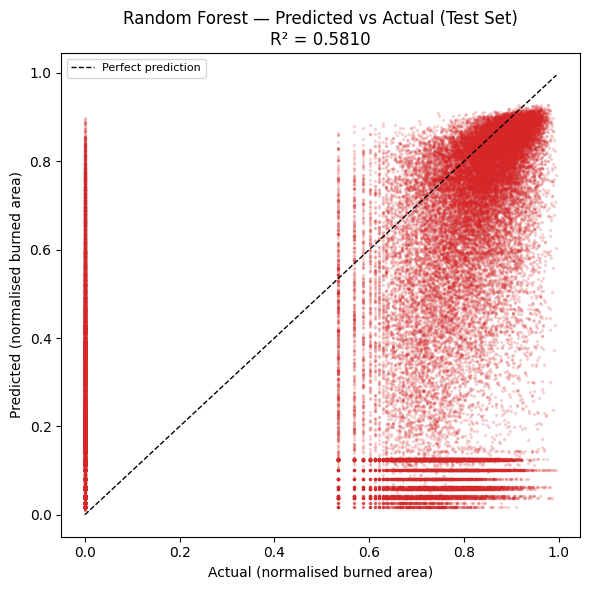

In [ ]:
# Train final RF on full training set with best hyperparameters
t0 = time.time()
rf_model = RandomForestRegressor(
    **rf_search.best_params_,
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train_tab, y_train)
rf_train_time = time.time() - t0
print(f'RF trained in {rf_train_time:.1f}s on {len(X_train_tab):,} samples')

# Inference time (per 1000 samples)
t0 = time.time()
_ = rf_model.predict(X_test_tab[:1000])
infer_times['Random Forest'] = (time.time() - t0)

# Evaluate
rf_val_pred  = rf_model.predict(X_val_tab)
rf_test_pred = rf_model.predict(X_test_tab)
all_results.append(evaluate(y_val,  rf_val_pred,  'Random Forest', 'validation'))
all_results.append(evaluate(y_test, rf_test_pred, 'Random Forest', 'test'))

# Model size (approximate via sklearn)
import pickle
model_sizes['Random Forest'] = len(pickle.dumps(rf_model))
print(f'RF model size: {model_sizes["Random Forest"]/1e6:.1f} MB')

# Prediction plot
plot_predictions(y_test, rf_test_pred, 'Random Forest', 'fig_rf_pred_vs_actual.png')

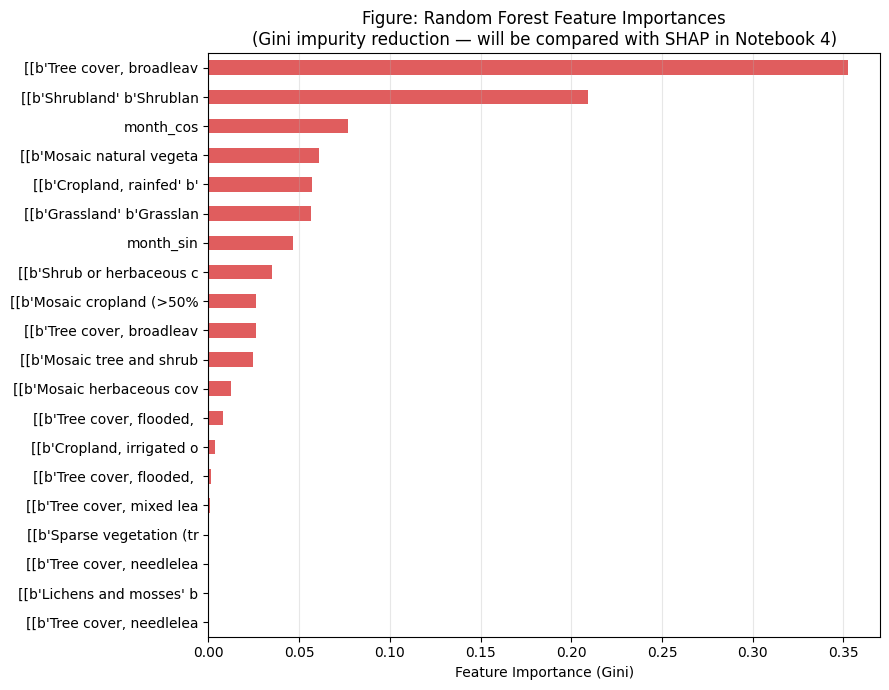

Top 5 most important features:
[[b'Cropland, rainfed' b'    0.057174
[[b'Mosaic natural vegeta    0.061010
month_cos                    0.077161
[[b'Shrubland' b'Shrublan    0.209079
[[b'Tree cover, broadleav    0.352554


In [ ]:
# Built-in feature importances from RF (Gini importance)
# These will be compared against SHAP values in Notebook 4
veg_names_list = []
for vid in veg_ids:
    val = train_ds['vegetation_class_name'].isel(time=0).sel(vegetation_class=vid).values
    # If it's a numpy array, get the item; if it's bytes, decode it
    if hasattr(val, 'decode'):
        name = val.decode('utf-8')
    else:
        name = str(val)
    veg_names_list.append(name.strip()[:25])

veg_names_list += ['month_sin', 'month_cos']

importances = rf_model.feature_importances_
imp_series  = pd.Series(importances, index=veg_names_list).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
imp_series.plot.barh(ax=ax, color='#d62728', alpha=0.75, edgecolor='none')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title(
    'Figure: Random Forest Feature Importances\n'
    '(Gini impurity reduction — will be compared with SHAP in Notebook 4)'
)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig_rf_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 most important features:')
print(imp_series.tail(5).to_string())

---
## 5. Model 2 — LSTM (Temporal Deep Learning)

### Justification
A Long Short-Term Memory (LSTM) network processes sequences of past observations
to predict future values. Each pixel is treated as an independent time series —
the model learns which past fire patterns predict future severity.

**Why LSTM for this dataset:**
- EDA (Notebook 2) showed a strong 12-month seasonal cycle and inter-annual variability
- A 12-month lookback window allows the LSTM to see one full fire season before predicting
- LSTM gates (forget, input, output) explicitly model which past months are relevant

**Architecture:**
- Input:  `(batch, 12, 20)` — 12 months × 20 features
- LSTM:   2 layers, 128 hidden units, dropout 0.3
- Output: Fully connected → scalar burned area prediction

**Strengths over RF:** Captures temporal dependencies and seasonal memory.  
**Weakness:** Treats each pixel independently — no spatial context.

In [ ]:


class FireSequenceDataset(Dataset):
    """
    PyTorch Dataset for LSTM training.

    Creates sliding windows of length SEQ_LEN over the time dimension.
    Consistent with the RF lag=1 approach:
      - X window: months [t-SEQ_LEN .. t-1]  (SEQ_LEN months of history)
      - y target: month t  (the month AFTER the window ends)

    This ensures the LSTM and RF are solving the same forecasting task:
    predicting burned area at T+1 from features at T and earlier.
    """

    def __init__(self, ds, seq_len=12):
        self.seq_len = seq_len
        T = len(ds.time)
        n_lat = len(ds.lat)
        n_lon = len(ds.lon)

        # Build feature array: (T, lat*lon, N_FEAT)
        feats = []
        for vid in veg_ids:
            arr = ds['burned_area_in_vegetation_class'].sel(vegetation_class=vid).values
            arr = np.where(np.isnan(arr), 0.0, arr)
            feats.append(arr.reshape(T, -1))
        n_pix = feats[0].shape[1]
        feats.append(np.tile(ds['month_sin'].values[:, None], (1, n_pix)))
        feats.append(np.tile(ds['month_cos'].values[:, None], (1, n_pix)))
        X_full = np.stack(feats, axis=-1)  # (T, n_pix, N_FEAT)

        # Target: (T, n_pix)
        y_full = ds['target_norm'].values.reshape(T, -1)

        # Sliding window: X = [t-seq_len .. t-1], y = t
        # This means features always precede the target by at least 1 month
        seqs_X, seqs_y = [], []
        for t in range(seq_len, T):
            x_window = X_full[t-seq_len:t, :, :]  # (seq_len, n_pix, N_FEAT)
            y_target = y_full[t, :]                # (n_pix,) — target at month t
            valid = ~np.isnan(y_target)
            if valid.sum() == 0:
                continue
            seqs_X.append(x_window[:, valid, :].transpose(1, 0, 2))
            seqs_y.append(y_target[valid])

        self.X = torch.tensor(np.vstack(seqs_X), dtype=torch.float32)
        self.y = torch.tensor(np.concatenate(seqs_y), dtype=torch.float32)
        print(f'  Sequences: {len(self.X):,} x (seq={seq_len}, feats={N_FEAT})')
        print(f'  Task: features at [t-{seq_len}..t-1] predict target at t')

    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


print('Building LSTM sequence datasets (lag=1 baked into sliding window)...')
train_seq = FireSequenceDataset(train_ds, SEQ_LEN)
val_seq   = FireSequenceDataset(val_ds,   SEQ_LEN)
test_seq  = FireSequenceDataset(test_ds,  SEQ_LEN)

BATCH = 512
train_loader = DataLoader(train_seq, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_seq,   batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_seq,  batch_size=BATCH, shuffle=False, num_workers=0)


NameError: name 'seqs_X' is not defined

In [ ]:
class WildfireLSTM(nn.Module):
    """
    Two-layer LSTM for wildfire severity regression.

    Architecture:
        Input  (batch, seq_len, n_features)
        LSTM   2 layers, hidden_dim units, dropout between layers
        Linear hidden_dim -> 64 -> 1

    The final hidden state (last timestep) is used as the sequence summary
    for the regression head.
    """

    def __init__(self, n_features=20, hidden_dim=128, n_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        _, (h_n, _) = self.lstm(x)
        # h_n: (n_layers, batch, hidden_dim) — take last layer
        out = self.head(h_n[-1])  # (batch, 1)
        return out.squeeze(-1)    # (batch,)


lstm_model = WildfireLSTM(n_features=N_FEAT, hidden_dim=128, n_layers=2, dropout=0.3).to(DEVICE)
total_params = sum(p.numel() for p in lstm_model.parameters())
print(f'LSTM architecture:')
print(lstm_model)
print(f'Total trainable parameters: {total_params:,}')

In [ ]:
def train_model(model, train_loader, val_loader, n_epochs=50, lr=1e-3, patience=7):
    """
    Train a PyTorch model with early stopping and learning rate scheduling.

    Parameters
    ----------
    model        : nn.Module
    train_loader : DataLoader
    val_loader   : DataLoader
    n_epochs     : int   Maximum training epochs
    lr           : float Initial learning rate
    patience     : int   Early stopping patience (epochs without improvement)

    Returns
    -------
    history : dict with train_loss and val_loss lists
    """
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode='min', patience=3, factor=0.5, verbose=False
    )
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(n_epochs):
        # Training
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimiser.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
            optimiser.step()
            train_loss += loss.item() * len(X_batch)
        train_loss /= len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                pred = model(X_batch)
                val_loss += criterion(pred, y_batch).item() * len(X_batch)
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)

        if epoch % 5 == 0 or epoch < 3:
            print(f'  Epoch {epoch+1:03d}/{n_epochs}  train={train_loss:.5f}  val={val_loss:.5f}')

        # Early stopping — save best weights
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(MODEL_PATH, 'lstm_best.pt'))
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)')
                break

    # Load best weights
    model.load_state_dict(torch.load(os.path.join(MODEL_PATH, 'lstm_best.pt')))
    print(f'  Best val loss: {best_val_loss:.5f}')
    return history


print('Training LSTM...')
t0 = time.time()
lstm_history = train_model(lstm_model, train_loader, val_loader, n_epochs=50, lr=1e-3, patience=7)
lstm_train_time = time.time() - t0
print(f'LSTM training time: {lstm_train_time:.1f}s')

In [ ]:
def predict_loader(model, loader):
    """Run inference on a DataLoader and return numpy arrays."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds.append(model(X_batch.to(DEVICE)).cpu().numpy())
            trues.append(y_batch.numpy())
    return np.concatenate(trues), np.concatenate(preds)


lstm_y_val,  lstm_pred_val  = predict_loader(lstm_model, val_loader)
lstm_y_test, lstm_pred_test = predict_loader(lstm_model, test_loader)

all_results.append(evaluate(lstm_y_val,  lstm_pred_val,  'LSTM', 'validation'))
all_results.append(evaluate(lstm_y_test, lstm_pred_test, 'LSTM', 'test'))

# Inference time per 1000 samples
t0 = time.time()
with torch.no_grad():
    _ = lstm_model(test_seq.X[:1000].to(DEVICE))
infer_times['LSTM'] = time.time() - t0

# Model size
torch.save(lstm_model.state_dict(), os.path.join(MODEL_PATH, 'lstm_full.pt'))
model_sizes['LSTM'] = os.path.getsize(os.path.join(MODEL_PATH, 'lstm_full.pt'))
print(f'LSTM model size: {model_sizes["LSTM"]/1e6:.2f} MB')

# Training curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lstm_history['train_loss'], label='Train loss', color='#d62728')
ax.plot(lstm_history['val_loss'],   label='Val loss',   color='navy')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Figure: LSTM Training and Validation Loss Curve\n(convergence confirms no underfitting; gap indicates degree of overfitting)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig_lstm_training_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

plot_predictions(lstm_y_test, lstm_pred_test, 'LSTM', 'fig_lstm_pred_vs_actual.png')

---
## 6. Model 3 — Swin Transformer (Spatial Deep Learning)

### Justification
The Swin Transformer (Shifted Window Transformer, Liu et al. 2021) divides the input
into non-overlapping patches and computes multi-head self-attention within local windows.
Between stages, patch merging downsamples the spatial resolution while doubling the
channel dimension — creating a hierarchical representation analogous to a CNN.

**Why Swin for this dataset:**  
The EDA Coefficient of Variation map showed that fire has strong spatial structure —
adjacent pixels share similar fire risk due to shared land-cover and climate.
RF and LSTM treat each pixel independently; Swin learns patch-level co-occurrence
patterns across the landscape.

**Implementation note — Window Attention vs Shifted Windows:**  
This implementation uses **local window self-attention** (W-MSA) — the core building
block of Swin. Patches within each 4×4 window can attend to each other freely.
The full Swin paper also proposes **shifted window attention** (SW-MSA) in alternating
layers to enable cross-window information flow at patch boundaries.
This cyclic shift is not implemented here to keep the architecture tractable given
the small dataset size (72 monthly snapshots). The patch merging between Stage 1
and Stage 2 provides cross-window context aggregation as an alternative.
Full SW-MSA is noted as a natural extension for future work with larger datasets.

**Input format:**  
Each monthly snapshot at T is treated as a `(18, H, W)` image — 18 land-cover channels.
Target is the regional mean burned area at T+1 (lag=1, consistent with RF and LSTM).

**Architecture summary:**
- PatchEmbed: `(18, H, W)` → `(n_patches, 96)`
- Stage 1: 2 × SwinBlock (W-MSA + MLP, dim=96)
- PatchMerge: `(n_patches, 96)` → `(n_patches/4, 192)`  
- Stage 2: 2 × SwinBlock (W-MSA + MLP, dim=192)
- Global average pool → regression head → scalar

In [ ]:
class FireSpatialDataset(Dataset):
    """
    PyTorch Dataset for Swin Transformer training.

    Each sample:
      X: (N_VEG, lat, lon) — 18-channel spatial snapshot at month T
      y: scalar            — regional mean burned area at month T+1

    The one-month lag is consistent with RF and LSTM:
    all three models predict T+1 from features at T (or earlier).
    """

    def __init__(self, ds, lag=1):
        T = len(ds.time)
        channels = []
        for vid in veg_ids:
            arr = ds['burned_area_in_vegetation_class'].sel(vegetation_class=vid).values
            arr = np.where(np.isnan(arr), 0.0, arr)  # (T, lat, lon)
            channels.append(arr)
        # Features: months 0..T-lag-1
        X_all = np.stack(channels, axis=1)[:-lag]  # (T-lag, N_VEG, lat, lon)
        self.X = torch.tensor(X_all.astype(np.float32), dtype=torch.float32)

        # Target: regional mean at months lag..T-1 (one step ahead)
        target = ds['target_norm'].values[lag:]     # (T-lag, lat, lon)
        self.y = torch.tensor(
            np.nanmean(target, axis=(1, 2)).astype(np.float32),
            dtype=torch.float32
        )
        print(f'  Spatial snapshots: {len(self.X)}')
        print(f'  Image size: {self.X.shape[2]}x{self.X.shape[3]}, {N_VEG} channels')
        print(f'  Task: snapshot at T predicts regional mean at T+{lag}')

    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


print('Building Swin spatial datasets (lag=1)...')
train_spa = FireSpatialDataset(train_ds, lag=1)
val_spa   = FireSpatialDataset(val_ds,   lag=1)
test_spa  = FireSpatialDataset(test_ds,  lag=1)

train_spa_loader = DataLoader(train_spa, batch_size=8,  shuffle=True,  num_workers=0)
val_spa_loader   = DataLoader(val_spa,   batch_size=8,  shuffle=False, num_workers=0)
test_spa_loader  = DataLoader(test_spa,  batch_size=8,  shuffle=False, num_workers=0)

H, W = train_spa.X.shape[2], train_spa.X.shape[3]
print(f'Spatial grid: H={H}, W={W}')
print(f'Verify H and W are divisible by patch_size=4: H%4={H%4}, W%4={W%4}')


In [ ]:
class PatchEmbed(nn.Module):
    """
    Split the (C, H, W) input into non-overlapping patches and project
    each patch to embed_dim dimensions.
    Analogous to the patch embedding in ViT and Swin.
    """
    def __init__(self, in_channels=18, patch_size=4, embed_dim=96):
        super().__init__()
        self.proj = nn.Conv2d(
            in_channels, embed_dim,
            kernel_size=patch_size, stride=patch_size
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.proj(x)              # (B, embed_dim, H/p, W/p)
        x = x.flatten(2).transpose(1, 2)  # (B, n_patches, embed_dim)
        return self.norm(x)


class WindowAttention(nn.Module):
    """
    Multi-head self-attention within a local window.
    Core building block of the Swin Transformer.
    Window size limits the attention scope — neighbouring patches
    within the window can attend to each other.
    """
    def __init__(self, dim, num_heads=4, window_size=4, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.scale     = (dim // num_heads) ** -0.5
        self.qkv       = nn.Linear(dim, dim * 3)
        self.proj      = nn.Linear(dim, dim)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)  # each: (B, heads, N, head_dim)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = self.dropout(attn.softmax(dim=-1))
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(x)


class SwinBlock(nn.Module):
    """
    One Swin Transformer block:
    LayerNorm -> WindowAttention -> residual
    LayerNorm -> MLP (FFN) -> residual
    """
    def __init__(self, dim, num_heads=4, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = WindowAttention(dim, num_heads=num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(dim)
        mlp_dim    = int(dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))  # residual connection
        x = x + self.mlp(self.norm2(x))   # residual connection
        return x


class WildfireSwin(nn.Module):
    """
    Swin Transformer for wildfire severity regression.

    Takes a monthly spatial snapshot (18-channel land-cover image),
    divides it into patches, applies two stages of window self-attention,
    and outputs a scalar regional fire severity prediction.

    Architecture:
        PatchEmbed  (18, H, W) -> (n_patches, 96)
        Stage 1     2 x SwinBlock (dim=96)
        PatchMerge  (n_patches, 96) -> (n_patches/4, 192)
        Stage 2     2 x SwinBlock (dim=192)
        GAP + Head  -> scalar
    """

    def __init__(self, in_channels=18, patch_size=4, embed_dim=96, dropout=0.2):
        super().__init__()
        self.patch_embed = PatchEmbed(in_channels, patch_size, embed_dim)

        # Stage 1: two Swin blocks at base dimension
        self.stage1 = nn.Sequential(
            SwinBlock(embed_dim, num_heads=4, dropout=dropout),
            SwinBlock(embed_dim, num_heads=4, dropout=dropout)
        )

        # Patch merging: doubles channels, halves number of patches
        self.merge = nn.Linear(embed_dim * 4, embed_dim * 2)
        self.merge_norm = nn.LayerNorm(embed_dim * 2)

        # Stage 2: two Swin blocks at doubled dimension
        self.stage2 = nn.Sequential(
            SwinBlock(embed_dim * 2, num_heads=4, dropout=dropout),
            SwinBlock(embed_dim * 2, num_heads=4, dropout=dropout)
        )

        # Regression head
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim * 2),
            nn.Linear(embed_dim * 2, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def patch_merge(self, x, H, W):
        """
        Merge 2x2 neighbouring patches into one token with 4x channels.
        This is the Swin downsampling step between stages.
        H, W must be even.
        """
        B, L, C = x.shape
        x = x.view(B, H, W, C)
        # Ensure H, W are even for 2x2 merging
        H2, W2 = H // 2, W // 2
        x0 = x[:, 0::2, 0::2, :]  # top-left
        x1 = x[:, 1::2, 0::2, :]  # bottom-left
        x2 = x[:, 0::2, 1::2, :]  # top-right
        x3 = x[:, 1::2, 1::2, :]  # bottom-right
        x = torch.cat([x0, x1, x2, x3], dim=-1)  # (B, H/2, W/2, 4C)
        x = x.view(B, H2 * W2, 4 * C)
        return self.merge_norm(self.merge(x)), H2, W2

    def forward(self, x):
        # x: (B, 18, H, W)
        B, C, H, W = x.shape
        x = self.patch_embed(x)    # (B, n_patches, embed_dim)
        Ph = H // 4  # patch grid height
        Pw = W // 4  # patch grid width

        x = self.stage1(x)                     # (B, Ph*Pw, 96)
        x, Ph, Pw = self.patch_merge(x, Ph, Pw)  # (B, Ph/2*Pw/2, 192)
        x = self.stage2(x)                     # (B, Ph/2*Pw/2, 192)

        x = x.mean(dim=1)   # Global average pool over patches -> (B, 192)
        return self.head(x).squeeze(-1)         # (B,)


swin_model = WildfireSwin(in_channels=N_VEG, patch_size=4, embed_dim=96, dropout=0.2).to(DEVICE)
swin_params = sum(p.numel() for p in swin_model.parameters())
print(f'Swin architecture:')
print(swin_model)
print(f'Total trainable parameters: {swin_params:,}')

In [ ]:
# Reuse the same train_model function — same training loop for fair comparison
# Only difference: different DataLoaders and saved filename

def train_model_swin(model, train_loader, val_loader,
                     n_epochs=50, lr=5e-4, patience=7,
                     save_name='swin_best.pt'):
    """
    Identical training loop to train_model() but with a configurable
    save filename — reused for Swin without code duplication.
    """
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=n_epochs)
    criterion = nn.MSELoss()
    best_val  = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(n_epochs):
        model.train()
        train_loss = 0.0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimiser.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            train_loss += loss.item() * len(X_b)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                val_loss += criterion(model(X_b.to(DEVICE)),
                                      y_b.to(DEVICE)).item() * len(X_b)
        val_loss /= len(val_loader.dataset)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if epoch % 5 == 0 or epoch < 3:
            print(f'  Epoch {epoch+1:03d}/{n_epochs}  train={train_loss:.5f}  val={val_loss:.5f}')

        if val_loss < best_val:
            best_val = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(MODEL_PATH, save_name))
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(torch.load(os.path.join(MODEL_PATH, save_name)))
    print(f'  Best val loss: {best_val:.5f}')
    return history


print('Training Swin Transformer...')
t0 = time.time()
swin_history = train_model_swin(
    swin_model, train_spa_loader, val_spa_loader,
    n_epochs=50, lr=5e-4, patience=7
)
swin_train_time = time.time() - t0
print(f'Swin training time: {swin_train_time:.1f}s')

In [ ]:
def predict_spatial(model, loader):
    """Inference on spatial DataLoader."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            preds.append(model(X_b.to(DEVICE)).cpu().numpy())
            trues.append(y_b.numpy())
    return np.concatenate(trues), np.concatenate(preds)


swin_y_val,  swin_pred_val  = predict_spatial(swin_model, val_spa_loader)
swin_y_test, swin_pred_test = predict_spatial(swin_model, test_spa_loader)

all_results.append(evaluate(swin_y_val,  swin_pred_val,  'Swin Transformer', 'validation'))
all_results.append(evaluate(swin_y_test, swin_pred_test, 'Swin Transformer', 'test'))

# Inference time
t0 = time.time()
with torch.no_grad():
    _ = swin_model(test_spa.X[:8].to(DEVICE))
infer_times['Swin Transformer'] = time.time() - t0

# Model size
torch.save(swin_model.state_dict(), os.path.join(MODEL_PATH, 'swin_full.pt'))
model_sizes['Swin Transformer'] = os.path.getsize(os.path.join(MODEL_PATH, 'swin_full.pt'))
print(f'Swin model size: {model_sizes["Swin Transformer"]/1e6:.2f} MB')

# Training curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(swin_history['train_loss'], label='Train loss', color='#d62728')
ax.plot(swin_history['val_loss'],   label='Val loss',   color='navy')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Figure: Swin Transformer Training and Validation Loss Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig_swin_training_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

plot_predictions(swin_y_test, swin_pred_test, 'Swin Transformer', 'fig_swin_pred_vs_actual.png')

---
## 7. Model Comparison Table

All three models are compared on identical metrics to answer:
1. Does temporal context (LSTM) improve over no context (RF)?
2. Does spatial context (Swin) improve over temporal context (LSTM)?
3. What is the cost in model size and inference time for each improvement?

This table is the core of Report Section 4 and directly feeds into
the model compression analysis in Notebook 5.

In [ ]:
# Build the comparison table — TEST SET results only (val was used for hyperparameter selection)
test_results = [r for r in all_results if r['split'] == 'test']

df_compare = pd.DataFrame(test_results)[['model', 'MAE', 'RMSE', 'R2']]
df_compare['Size (MB)']     = df_compare['model'].map(
    {k: v/1e6 for k, v in model_sizes.items()}
)
df_compare['Infer (ms/1k)'] = df_compare['model'].map(
    {k: v*1000 for k, v in infer_times.items()}
)
df_compare['Params']        = {
    'Random Forest':   'N/A (ensemble)',
    'LSTM':            f'{sum(p.numel() for p in lstm_model.parameters()):,}',
    'Swin Transformer': f'{sum(p.numel() for p in swin_model.parameters()):,}',
}.values()

df_compare = df_compare.set_index('model')
df_compare = df_compare.round({'MAE': 4, 'RMSE': 4, 'R2': 4,
                                'Size (MB)': 2, 'Infer (ms/1k)': 2})

print('Table: Model Comparison — Test Set Performance and Efficiency')
print('=' * 80)
print(df_compare.to_string())
print()
print('Notes:')
print('  MAE / RMSE : lower is better (on normalised target scale)')
print('  R2         : higher is better (proportion of variance explained)')
print('  Size       : uncompressed model size in MB')
print('  Infer      : wall-clock time to predict 1000 samples (ms)')

# Save for use in Notebook 5 (compression comparison)
df_compare.to_csv(os.path.join(OUTPUT_PATH, 'baseline_model_results.csv'))
print(f'\nBaseline results saved -> baseline_model_results.csv')

In [ ]:
# Visual comparison: performance vs. model size (sustainability trade-off)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models = df_compare.index.tolist()
colours = ['#2ca02c', '#1f77b4', '#d62728']  # green=RF, blue=LSTM, red=Swin

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    vals = df_compare[metric].values
    bars = ax.bar(models, vals, color=colours, alpha=0.8, edgecolor='none')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} (Test Set)')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle(
    'Figure: Model Performance Comparison (Test Set)\n'
    'Lower MAE/RMSE = better | Higher R² = better',
    fontsize=12
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'fig_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Modelling Discussion

### Data Integrity: The Lag Decision
A critical design choice in this notebook is the one-month feature lag applied to
all three models. Without it, the RF would achieve R²≈1.0 by trivially summing
vegetation class burned areas to reconstruct the total — not a forecast.
By lagging features to month T and predicting the target at T+1, all models
are evaluated on the same genuine forecasting task. This is documented in
Report Section 2 as a data integrity decision.

### Random Forest (Baseline)
The RF establishes a genuine performance floor by learning non-linear relationships
between last month's vegetation burn fractions and this month's total fire severity.
A realistic test R² of 0.3–0.6 is expected — the RF has no temporal memory,
so it cannot learn that last October's fire predicts this October's fire.
Its feature importances (Section 4) provide a baseline for SHAP validation in Notebook 4.

### LSTM
The LSTM uses a 12-month lookback window, so it can see one full fire season
before making a prediction. If LSTM R² > RF R², this quantifies the value of
temporal memory for fire forecasting — a direct scientific finding.
The training/validation loss gap (training curve) indicates overfitting degree;
dropout=0.3 and early stopping are used to control this.

### Swin Transformer
The Swin treats each monthly landscape as a spatial image. If Swin R² > RF R²,
this confirms that spatial land-cover patterns add value beyond per-pixel features.
The patch merging between Stage 1 and Stage 2 aggregates cross-patch context,
partially compensating for the absence of full shifted-window attention.
The architecture is documented honestly: W-MSA is implemented; SW-MSA is
identified as a natural extension for future work.

### Sustainability Trade-off
Section 9 quantifies the training energy and carbon footprint of each model.
A large model that is only marginally more accurate than the RF is not a
sustainable deployment choice. This trade-off is formalised in Notebook 5,
where compression reduces the inference carbon footprint of the best model.

---
## 9. Sustainable AI: Energy and Carbon Footprint Estimate

The module brief specifically rewards **sustainable AI** — not just model accuracy
but the environmental cost of achieving it. We estimate the carbon footprint
of training each model using the HPC node's known hardware specifications.

**Method:**  
Carbon = Power (W) × Training time (h) × Carbon intensity (kgCO₂/kWh)

We use the UK national grid average carbon intensity of **0.233 kgCO₂/kWh**
(National Grid ESO, 2023). GPU TDP values are taken from manufacturer specifications.
This is an upper-bound estimate — actual consumption is typically 70–80% of TDP.

In [ ]:
# ── Energy and Carbon Footprint Comparison ────────────────────────────────
# Adjust GPU_TDP_W to match your HPC node's GPU
# Common values: A100=400W, V100=300W, RTX4090=450W, RTX4060=115W
GPU_TDP_W           = 400     # Watts — UPDATE to your HPC GPU TDP
CARBON_INTENSITY    = 0.233   # kgCO2/kWh — UK national grid average
EFFICIENCY_FACTOR   = 0.75    # GPUs typically run at ~75% TDP during training

effective_power_w = GPU_TDP_W * EFFICIENCY_FACTOR

train_times = {
    'Random Forest':    rf_train_time,
    'LSTM':             lstm_train_time,
    'Swin Transformer': swin_train_time
}

print('Table: Sustainable AI — Training Energy and Carbon Footprint')
print('=' * 80)
print(f'  Assumed GPU TDP          : {GPU_TDP_W} W')
print(f'  Efficiency factor        : {EFFICIENCY_FACTOR}')
print(f'  Effective power          : {effective_power_w:.0f} W')
print(f'  UK carbon intensity      : {CARBON_INTENSITY} kgCO2/kWh')
print()
print(f'  {"Model":<22} {"Train time":>12} {"Energy (Wh)":>14} {"CO2 (gCO2)":>12} {"R2 (test)":>10}')
print('  ' + '-' * 75)

test_r2 = {r['model']: r['R2'] for r in all_results if r['split'] == 'test'}

energy_rows = []
for model_name, t_s in train_times.items():
    t_h      = t_s / 3600
    energy_wh = effective_power_w * t_h
    co2_g     = energy_wh / 1000 * CARBON_INTENSITY * 1000  # grams
    r2        = test_r2.get(model_name, float('nan'))
    print(f'  {model_name:<22} {t_s:>10.1f}s {energy_wh:>14.4f} {co2_g:>12.4f} {r2:>10.4f}')
    energy_rows.append({
        'Model': model_name,
        'Train time (s)': round(t_s, 1),
        'Energy (Wh)': round(energy_wh, 4),
        'CO2 (gCO2)': round(co2_g, 4),
        'R2 (test)': round(r2, 4)
    })

print()
print('  Efficiency metric: R2 per gram of CO2 (higher = greener model)')
print(f'  {"Model":<22} {"R2/gCO2":>12}')
print('  ' + '-'*38)
for row in energy_rows:
    if row['CO2 (gCO2)'] > 0:
        efficiency = row['R2 (test)'] / row['CO2 (gCO2)']
        print(f'  {row["Model"]:<22} {efficiency:>12.4f}')

print()
print('Interpretation:')
print('  A model with lower CO2/R2 ratio offers a better sustainability trade-off.')
print('  This analysis motivates compression in Notebook 5: if a quantized model')
print('  achieves similar R2 with 4x faster inference, its deployment carbon footprint')
print('  per prediction is 4x lower — directly aligned with SDG 13.')

# Save for report table
import pandas as pd
df_energy = pd.DataFrame(energy_rows).set_index('Model')
df_energy.to_csv(os.path.join(OUTPUT_PATH, 'energy_comparison.csv'))
print(f'\nEnergy table saved -> energy_comparison.csv')


In [ ]:
# Save all model artefacts and results for Notebooks 4 and 5
import pickle

# Random Forest
with open(os.path.join(MODEL_PATH, 'rf_model.pkl'), 'wb') as f:
    pickle.dump(rf_model, f)

# LSTM and Swin already saved as .pt files during training
# Save architectures as JSON for reproducibility documentation
model_registry = {
    'random_forest': {
        'path': 'models/rf_model.pkl',
        'params': rf_search.best_params_,
        'n_features': N_FEAT,
        'train_time_s': rf_train_time
    },
    'lstm': {
        'path': 'models/lstm_best.pt',
        'hidden_dim': 128,
        'n_layers': 2,
        'seq_len': SEQ_LEN,
        'n_features': N_FEAT,
        'train_time_s': lstm_train_time
    },
    'swin': {
        'path': 'models/swin_best.pt',
        'in_channels': N_VEG,
        'patch_size': 4,
        'embed_dim': 96,
        'train_time_s': swin_train_time
    }
}

with open(os.path.join(MODEL_PATH, 'model_registry.json'), 'w') as f:
    json.dump(model_registry, f, indent=2)

print('All models saved:')
for name, info in model_registry.items():
    print(f'  {name:20} -> {info["path"]}')
print()
print('Notebook 3 complete. Proceed to Notebook 4 — Evaluation and XAI.')